<div style="text-align: center;">
<h1 style = "color:#4c8fc4;">PROYECTO</h1>

Profesor:
* Lopez Gomez Alejandro
*
Alumnos:
* Mendiola Gómez Juan Carlos
* Molina Montaño Fidel Uriel
* Ramirez Morales Adriana
</div>

<div style="text-align: center;">
<h1 style = "color:#d35400;">TRANSPORTE URBANO DE PASAJEROS</h1>
</div>
I. Para este programa se utilizará el dataset:  etup_mensual_tr_cifra_1986_2025.csv el cual pertenece a datos abiertos de la pagina del INEGI: https://www.inegi.org.mx/datosabiertos/

II. catalogos:  tc_entidad.csv, tc_municipio.csv, tc_periodo_mes.csv

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv("etup_mensual_tr_cifra_1986_2025.csv")

In [45]:
def get_unique_values(df):

    dictionary = {
        'Data type': [],
        'Amount': [],
        'Unique values': []
    }

    for column in df.columns:
        unique_values = df[column].unique() #function unique for get unique values for each column

        dictionary['Data type'].append(df[column].dtype) #we add the types data to list
        dictionary['Amount'].append(len(unique_values)) #function len()
        dictionary['Unique values'].append(unique_values)

    df_unique_values = pd.DataFrame(dictionary, index=df.columns)


    return df_unique_values

In [46]:
df

,ANIO,ID_MES,TRANSPORTE,VARIABLE,ID_ENTIDAD,ID_MUNICIPIO,VALOR,ESTATUS
0,1986,1,Red de Transporte de Pasajeros,Autobuses en operación de lunes a viernes,9,999,4201.0,Cifras Definitivas
1,1986,1,Red de Transporte de Pasajeros,Autobuses en operación de sábado a domingo,9,999,2601.0,Cifras Definitivas
2,1986,1,Red de Transporte de Pasajeros,Kilómetros recorridos,9,999,27199400.0,Cifras Definitivas
3,1986,1,Red de Transporte de Pasajeros,Pasajeros transportados,9,999,172000400.0,Cifras Definitivas
4,1986,1,Red de Transporte de Pasajeros,Personal ocupado,9,999,22451.0,Cifras Definitivas
...,...,...,...,...,...,...,...,...
29734,2025,3,Qrobús,Pasajeros transportados,22,14,497095.0,Cifras Preliminares
29735,2025,3,Qrobús,Pasajeros transportados con boleto pagado,22,14,283552.0,Cifras Preliminares
29736,2025,3,Qrobús,Pasajeros transportados con cortesía,22,14,0.0,Cifras Preliminares
29737,2025,3,Qrobús,Pasajeros transportados con descuento,22,14,213543.0,Cifras Preliminares


In [47]:
unique_values_incial = get_unique_values(df)
unique_values_incial

,Data type,Amount,Unique values
ANIO,int64,40,"[1986, 1987, 1988, 1989, 1990, 1991, 1992, 199..."
ID_MES,int64,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
TRANSPORTE,object,27,"[Red de Transporte de Pasajeros, Sistema de Tr..."
VARIABLE,object,19,"[Autobuses en operación de lunes a viernes, Au..."
ID_ENTIDAD,int64,10,"[9, 19, 14, 15, 22, 13, 8, 11, 21, 12]"
ID_MUNICIPIO,int64,8,"[999, 39, 14, 48, 19, 20, 114, 1]"
VALOR,float64,15256,"[4201.0, 2601.0, 27199400.0, 172000400.0, 2245..."
ESTATUS,object,3,"[Cifras Definitivas, Cifras Preliminares, Cifr..."


In [48]:
df.shape

(29739, 8)

In [49]:
total_filas = 29739

In [50]:
df.columns

Index(['ANIO', 'ID_MES', 'TRANSPORTE', 'VARIABLE', 'ID_ENTIDAD',
       'ID_MUNICIPIO', 'VALOR', 'ESTATUS'],
      dtype='object')

In [51]:
d = df[df.duplicated()]
d_s = df.duplicated().sum()
d_s

0

Como tenemos muchos 999, se hace el conteo total ya que estos en el catalogo de datos significan "otros municipios"

In [52]:
municipios = df["ID_MUNICIPIO"].value_counts()[999]

print(f'Municipios sin nombre = {municipios}')
print(f'La suma de ambos = {round(((municipios/total_filas)*100),2)}%')

Municipios sin nombre = 12869
La suma de ambos = 43.27%


In [53]:
var_ENT = df["ID_ENTIDAD"].unique()

for ent in var_ENT:
    count = ((df['ID_ENTIDAD'] == ent) & (df['ID_MUNICIPIO'] == 999)).sum()
    print(f"Entidad {ent} con municipio 999: {count} fila(s)")

Entidad 9 con municipio 999: 11145 fila(s)
Entidad 19 con municipio 999: 0 fila(s)
Entidad 14 con municipio 999: 0 fila(s)
Entidad 15 con municipio 999: 1724 fila(s)
Entidad 22 con municipio 999: 0 fila(s)
Entidad 13 con municipio 999: 0 fila(s)
Entidad 8 con municipio 999: 0 fila(s)
Entidad 11 con municipio 999: 0 fila(s)
Entidad 21 con municipio 999: 0 fila(s)
Entidad 12 con municipio 999: 0 fila(s)


In [54]:
# 2. Cargar el archivo con nombres de los meses
df_meses = pd.read_csv("tc_periodo_mes.csv")

# 3. Crear el diccionario de mapeo: {1: 'Enero', 2: 'Febrero', ...}
dic_meses = df_meses.set_index("ID_MES")["MES"].to_dict()

# 4. Mapear los números a nombres en una nueva columna
df["MES"] = df["ID_MES"].map(dic_meses)

In [55]:
df_entidad = pd.read_csv("tc_entidad.csv")

dic_entidad = df_entidad.set_index("ID_ENTIDAD")["NOM_ENTIDAD"].to_dict()

df["ENTIDAD"] = df["ID_ENTIDAD"].map(dic_entidad)

In [56]:
df_municipio = pd.read_csv("tc_municipio.csv")

df = df.merge(
    df_municipio[["ID_ENTIDAD", "ID_MUNICIPIO", "NOM_MUNICIPIO"]],
    on=["ID_ENTIDAD", "ID_MUNICIPIO"],
    how="left"
)
df = df.rename(columns={"NOM_MUNICIPIO": "MUNICIPIO"})

# para "Otros municipios" se remplaza por el nombre de la entidad completa
mask = df["MUNICIPIO"] == "Otros municipios"
df.loc[mask, "MUNICIPIO"] = df.loc[mask, "ENTIDAD"]

Catalogo para ID_entidad:
- 8 = Chihuahua
- 9 = Ciudad de México
- 11 = Guanajuato
- 12 = Guerrero
- 13 = Hidalgo
- 14 = Jalisco
- 15 = Estado de México
- 19 = Nuevo Leon
- 22 = Queretaro

Para el caso de municipios, se requiere saber a que entidad esta asociado para concentrarnos en esos municipios, en todos los casos 999 se maneja como "otros municipios"
Catalogo para ID_municipio:
- 1
- 14
- 19
- 20
- 39
- 48
- 114
- 999

In [57]:
variables_del_dataset = pd.DataFrame(df["VARIABLE"].unique())
variables_del_dataset

,0
0,Autobuses en operación de lunes a viernes
1,Autobuses en operación de sábado a domingo
2,Kilómetros recorridos
3,Pasajeros transportados
4,Personal ocupado
5,Rutas
6,Energía eléctrica consumida
7,Longitud de servicio
8,Trenes en servicio
9,Ingresos por pasaje


no nos interesa las variables de:
* personal ocupado
* longitud de servicio
* trenes en servicio
* Pasajeros trasportados con cortesía
* Pasajeros transportados con boleto pagado
* Unidades en existencia
* Pasajeros transportados con descuento
* Cabinas en operación de lunes a
* Pasajeros transportados con cortesía
* Cabinas en operación de sábado a domingo
* Pasajeros transportados con transbordo

In [58]:
df = df.drop(['ID_MES', 'ID_ENTIDAD', 'ID_MUNICIPIO', 'ESTATUS'], axis=1)

In [59]:
# Lista de variables que no nos interesan
variables_a_eliminar = [
    'Personal ocupado',
    'Longitud de servicio',
    'Trenes en servicio',
    'Pasajeros trasportados con cortesía',
    'Pasajeros transportados con boleto pagado',
    'Unidades en existencia',
    'Pasajeros transportados con descuento',
    'Cabinas en operación de lunes a viernes',
    'Cabinas en operación de sábado a domingo',
    'Pasajeros transportados con transbordo',
    'Pasajeros transportados con cortesía'
]

# Opción 2: Eliminar las filas que SÍ están en la lista (equivalente a la opción 1)
#df = df.drop(df[df['VARIABLE'].isin(variables_a_eliminar)].index)
df

,ANIO,TRANSPORTE,VARIABLE,VALOR,MES,ENTIDAD,MUNICIPIO
0,1986,Red de Transporte de Pasajeros,Autobuses en operación de lunes a viernes,4201.0,Enero,Ciudad de México,Ciudad de México
1,1986,Red de Transporte de Pasajeros,Autobuses en operación de sábado a domingo,2601.0,Enero,Ciudad de México,Ciudad de México
2,1986,Red de Transporte de Pasajeros,Kilómetros recorridos,27199400.0,Enero,Ciudad de México,Ciudad de México
3,1986,Red de Transporte de Pasajeros,Pasajeros transportados,172000400.0,Enero,Ciudad de México,Ciudad de México
4,1986,Red de Transporte de Pasajeros,Personal ocupado,22451.0,Enero,Ciudad de México,Ciudad de México
...,...,...,...,...,...,...,...
29734,2025,Qrobús,Pasajeros transportados,497095.0,Marzo,Querétaro,Querétaro
29735,2025,Qrobús,Pasajeros transportados con boleto pagado,283552.0,Marzo,Querétaro,Querétaro
29736,2025,Qrobús,Pasajeros transportados con cortesía,0.0,Marzo,Querétaro,Querétaro
29737,2025,Qrobús,Pasajeros transportados con descuento,213543.0,Marzo,Querétaro,Querétaro


In [60]:
unique_values = get_unique_values(df)
unique_values

,Data type,Amount,Unique values
ANIO,int64,40,"[1986, 1987, 1988, 1989, 1990, 1991, 1992, 199..."
TRANSPORTE,object,27,"[Red de Transporte de Pasajeros, Sistema de Tr..."
VARIABLE,object,19,"[Autobuses en operación de lunes a viernes, Au..."
VALOR,float64,15256,"[4201.0, 2601.0, 27199400.0, 172000400.0, 2245..."
MES,object,12,"[Enero, Febrero, Marzo, Abril, Mayo, Junio, Ju..."
ENTIDAD,object,10,"[Ciudad de México, Nuevo León, Jalisco, México..."
MUNICIPIO,object,10,"[Ciudad de México, Monterrey, Guadalajara, Méx..."


In [61]:
missing_values = df.isnull().sum()
print(missing_values)

ANIO            0
TRANSPORTE      0
VARIABLE        0
VALOR         300
MES             0
ENTIDAD         0
MUNICIPIO       0
dtype: int64


In [62]:
porcentaje_nulos = (missing_values / total_filas) * 100
porcentaje_nulos

ANIO          0.000000
TRANSPORTE    0.000000
VARIABLE      0.000000
VALOR         1.008776
MES           0.000000
ENTIDAD       0.000000
MUNICIPIO     0.000000
dtype: float64

Como representan menos del 5% serán eliminados.

In [63]:
#df = df.dropna()  # elimina filas con al menos un nulo
missing_values = df.isnull().sum()
print(missing_values)

ANIO            0
TRANSPORTE      0
VARIABLE        0
VALOR         300
MES             0
ENTIDAD         0
MUNICIPIO       0
dtype: int64


In [64]:
df.shape

(29739, 7)

In [65]:
numerics = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

print('\nnumerics variables')
print(numerics)
print('\ncategorical variables')
print(categorical)


numerics variables
['ANIO', 'VALOR']

categorical variables
['TRANSPORTE', 'VARIABLE', 'MES', 'ENTIDAD', 'MUNICIPIO']


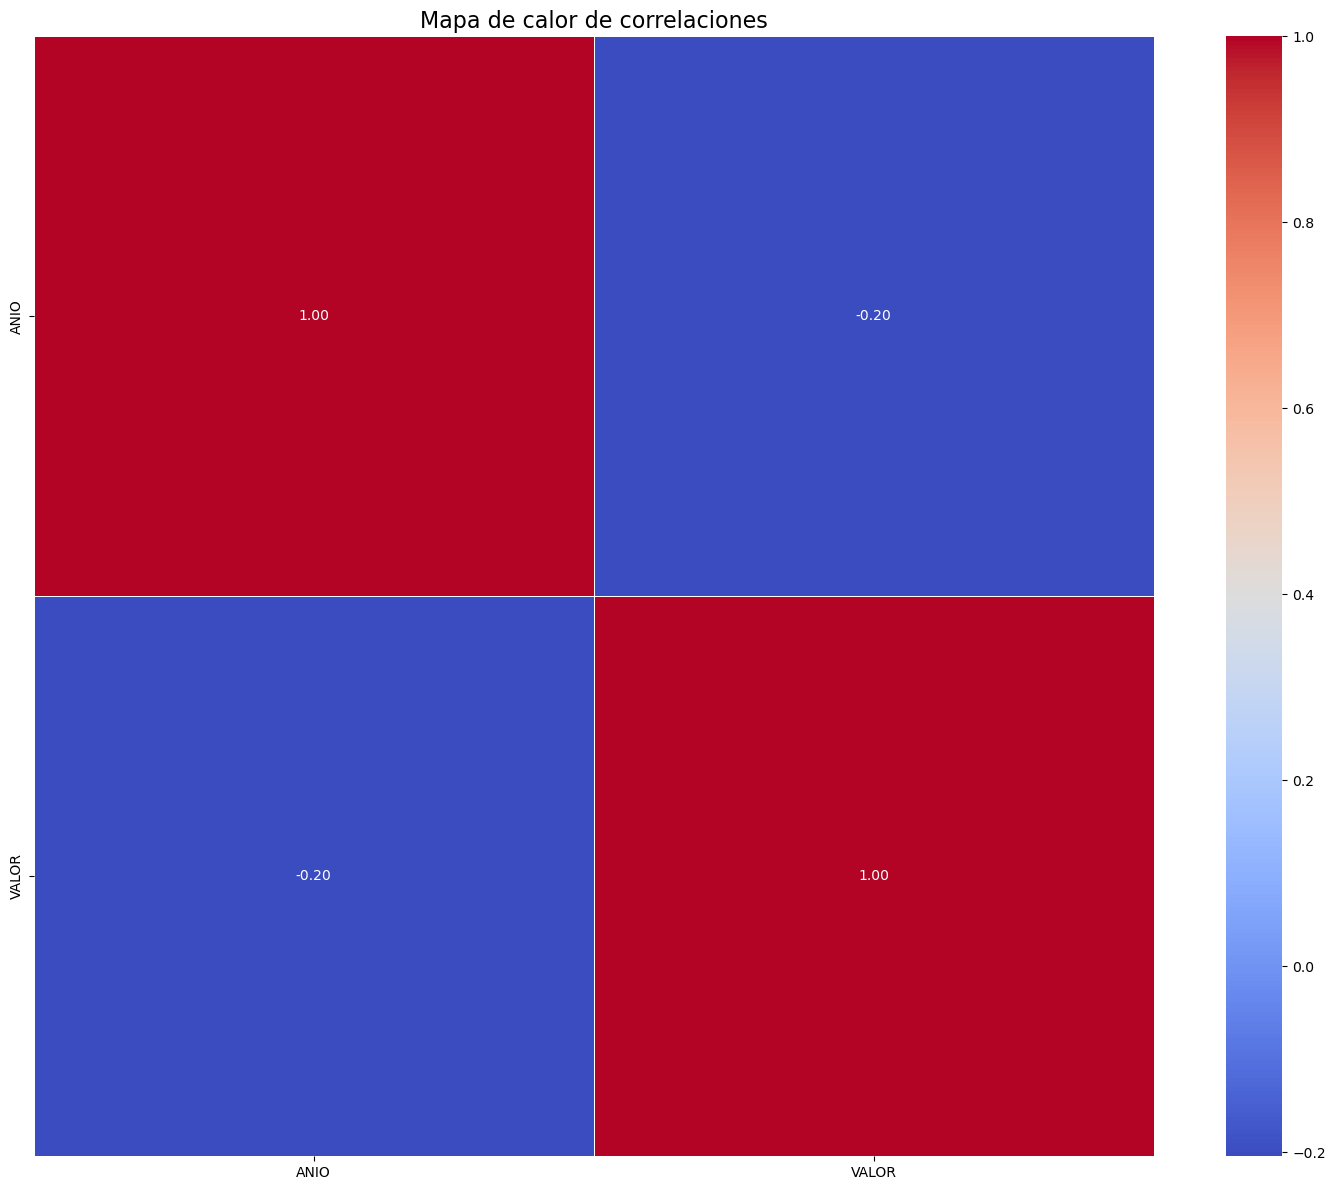

In [66]:
# matriz de correlación
corr_matrix = df[numerics].corr()

# Crear el mapa de calor
plt.figure(figsize=(15, 12))  # Tamaño de la figura
sns.heatmap(corr_matrix,
            annot=True,      # Mostrar los valores dentro de las celdas
            fmt=".2f",       # Formato de los números
            cmap="coolwarm", # Paleta de colores
            cbar=True,       # Mostrar barra de colores
            square=True,     # Celdas cuadradas
            linewidths=0.5)  # Líneas entre celdas
plt.title('Mapa de calor de correlaciones', fontsize=16)
plt.tight_layout()  # Ajustar márgenes
plt.show()

In [67]:
# Guardar como archivo Excel
#df.to_excel("transporte_definitivo.xlsx", index=False)

In [68]:
df

,ANIO,TRANSPORTE,VARIABLE,VALOR,MES,ENTIDAD,MUNICIPIO
0,1986,Red de Transporte de Pasajeros,Autobuses en operación de lunes a viernes,4201.0,Enero,Ciudad de México,Ciudad de México
1,1986,Red de Transporte de Pasajeros,Autobuses en operación de sábado a domingo,2601.0,Enero,Ciudad de México,Ciudad de México
2,1986,Red de Transporte de Pasajeros,Kilómetros recorridos,27199400.0,Enero,Ciudad de México,Ciudad de México
3,1986,Red de Transporte de Pasajeros,Pasajeros transportados,172000400.0,Enero,Ciudad de México,Ciudad de México
4,1986,Red de Transporte de Pasajeros,Personal ocupado,22451.0,Enero,Ciudad de México,Ciudad de México
...,...,...,...,...,...,...,...
29734,2025,Qrobús,Pasajeros transportados,497095.0,Marzo,Querétaro,Querétaro
29735,2025,Qrobús,Pasajeros transportados con boleto pagado,283552.0,Marzo,Querétaro,Querétaro
29736,2025,Qrobús,Pasajeros transportados con cortesía,0.0,Marzo,Querétaro,Querétaro
29737,2025,Qrobús,Pasajeros transportados con descuento,213543.0,Marzo,Querétaro,Querétaro


# SEGUNDA PARTE DEL PROYECTO: APLICANDO PCA

### PIVOTEAR LA COLUMNA VARIABLE

In [69]:
# Pivoteo con agregación (suma de valores repetidos)
df_wide = df.pivot_table(
    index=['ANIO', 'MES', 'ENTIDAD', 'TRANSPORTE'],
    columns='VARIABLE',
    values='VALOR',
    aggfunc='sum',  # También puede ser 'mean', 'first', etc.
    fill_value=0    # Opcional: reemplaza NaN con 0
).reset_index()

In [70]:
df_wide

VARIABLE,ANIO,MES,ENTIDAD,TRANSPORTE,Autobuses en operación de lunes a viernes,Autobuses en operación de sábado a domingo,Cabinas en operación de lunes a viernes,Cabinas en operación de sábado a domingo,Energía eléctrica consumida,Ingresos por pasaje,...,Pasajeros transportados,Pasajeros transportados con boleto pagado,Pasajeros transportados con cortesía,Pasajeros transportados con descuento,Pasajeros transportados con transbordo,Personal ocupado,Rutas,Trenes en servicio,Unidades en existencia,Unidades en operación
0,1986,Abril,Ciudad de México,Red de Transporte de Pasajeros,4320.0,2633.0,0.0,0.0,0.0,0.0,...,171699000.0,0.0,0.0,0.0,0.0,22542.0,220.0,0.0,0.0,0.0
1,1986,Abril,Ciudad de México,Sistema de Transporte Colectivo Metro,0.0,0.0,0.0,0.0,58166000.0,0.0,...,112752000.0,0.0,0.0,0.0,0.0,0.0,0.0,152.0,0.0,0.0
2,1986,Agosto,Ciudad de México,Red de Transporte de Pasajeros,4145.0,2688.0,0.0,0.0,0.0,0.0,...,167099300.0,0.0,0.0,0.0,0.0,22714.0,222.0,0.0,0.0,0.0
3,1986,Agosto,Ciudad de México,Sistema de Transporte Colectivo Metro,0.0,0.0,0.0,0.0,61739000.0,0.0,...,120106400.0,0.0,0.0,0.0,0.0,0.0,0.0,158.0,0.0,0.0
4,1986,Diciembre,Ciudad de México,Red de Transporte de Pasajeros,4621.0,2614.0,0.0,0.0,0.0,0.0,...,206199600.0,0.0,0.0,0.0,0.0,22474.0,224.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4775,2025,Marzo,Nuevo León,Sistema de Transporte Colectivo Metrorrey,0.0,0.0,0.0,0.0,3822560.0,84957506.0,...,8351842.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,0.0
4776,2025,Marzo,Nuevo León,Transmetro,270.0,240.0,0.0,0.0,0.0,0.0,...,3353217.0,0.0,0.0,0.0,0.0,716.0,31.0,0.0,0.0,0.0
4777,2025,Marzo,Nuevo León,Transmetro García-Monterrey-Guadalupe,39.0,22.0,0.0,0.0,0.0,0.0,...,910620.0,910620.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4778,2025,Marzo,Puebla,Red Urbana de Transporte Articulado,349.0,270.0,0.0,0.0,0.0,0.0,...,8467545.0,8252959.0,214586.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0


In [71]:
df_wide['ANIO'] = df_wide['ANIO'].astype('object')

In [72]:
numerics = df_wide.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df_wide.select_dtypes(include=['object']).columns.tolist()

print('\nnumerics variables')
print(numerics)
print('\ncategorical variables')
print(categorical)

df_wide


numerics variables
['Autobuses en operación de lunes a viernes', 'Autobuses en operación de sábado a domingo', 'Cabinas en operación de lunes a viernes', 'Cabinas en operación de sábado a domingo', 'Energía eléctrica consumida', 'Ingresos por pasaje', 'Kilómetros recorridos', 'Lineas en servicio', 'Longitud de servicio', 'Pasajeros transportados', 'Pasajeros transportados con boleto pagado', 'Pasajeros transportados con cortesía', 'Pasajeros transportados con descuento', 'Pasajeros transportados con transbordo', 'Personal ocupado', 'Rutas', 'Trenes en servicio', 'Unidades en existencia', 'Unidades en operación']

categorical variables
['ANIO', 'MES', 'ENTIDAD', 'TRANSPORTE']


VARIABLE,ANIO,MES,ENTIDAD,TRANSPORTE,Autobuses en operación de lunes a viernes,Autobuses en operación de sábado a domingo,Cabinas en operación de lunes a viernes,Cabinas en operación de sábado a domingo,Energía eléctrica consumida,Ingresos por pasaje,...,Pasajeros transportados,Pasajeros transportados con boleto pagado,Pasajeros transportados con cortesía,Pasajeros transportados con descuento,Pasajeros transportados con transbordo,Personal ocupado,Rutas,Trenes en servicio,Unidades en existencia,Unidades en operación
0,1986,Abril,Ciudad de México,Red de Transporte de Pasajeros,4320.0,2633.0,0.0,0.0,0.0,0.0,...,171699000.0,0.0,0.0,0.0,0.0,22542.0,220.0,0.0,0.0,0.0
1,1986,Abril,Ciudad de México,Sistema de Transporte Colectivo Metro,0.0,0.0,0.0,0.0,58166000.0,0.0,...,112752000.0,0.0,0.0,0.0,0.0,0.0,0.0,152.0,0.0,0.0
2,1986,Agosto,Ciudad de México,Red de Transporte de Pasajeros,4145.0,2688.0,0.0,0.0,0.0,0.0,...,167099300.0,0.0,0.0,0.0,0.0,22714.0,222.0,0.0,0.0,0.0
3,1986,Agosto,Ciudad de México,Sistema de Transporte Colectivo Metro,0.0,0.0,0.0,0.0,61739000.0,0.0,...,120106400.0,0.0,0.0,0.0,0.0,0.0,0.0,158.0,0.0,0.0
4,1986,Diciembre,Ciudad de México,Red de Transporte de Pasajeros,4621.0,2614.0,0.0,0.0,0.0,0.0,...,206199600.0,0.0,0.0,0.0,0.0,22474.0,224.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4775,2025,Marzo,Nuevo León,Sistema de Transporte Colectivo Metrorrey,0.0,0.0,0.0,0.0,3822560.0,84957506.0,...,8351842.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,0.0
4776,2025,Marzo,Nuevo León,Transmetro,270.0,240.0,0.0,0.0,0.0,0.0,...,3353217.0,0.0,0.0,0.0,0.0,716.0,31.0,0.0,0.0,0.0
4777,2025,Marzo,Nuevo León,Transmetro García-Monterrey-Guadalupe,39.0,22.0,0.0,0.0,0.0,0.0,...,910620.0,910620.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4778,2025,Marzo,Puebla,Red Urbana de Transporte Articulado,349.0,270.0,0.0,0.0,0.0,0.0,...,8467545.0,8252959.0,214586.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0


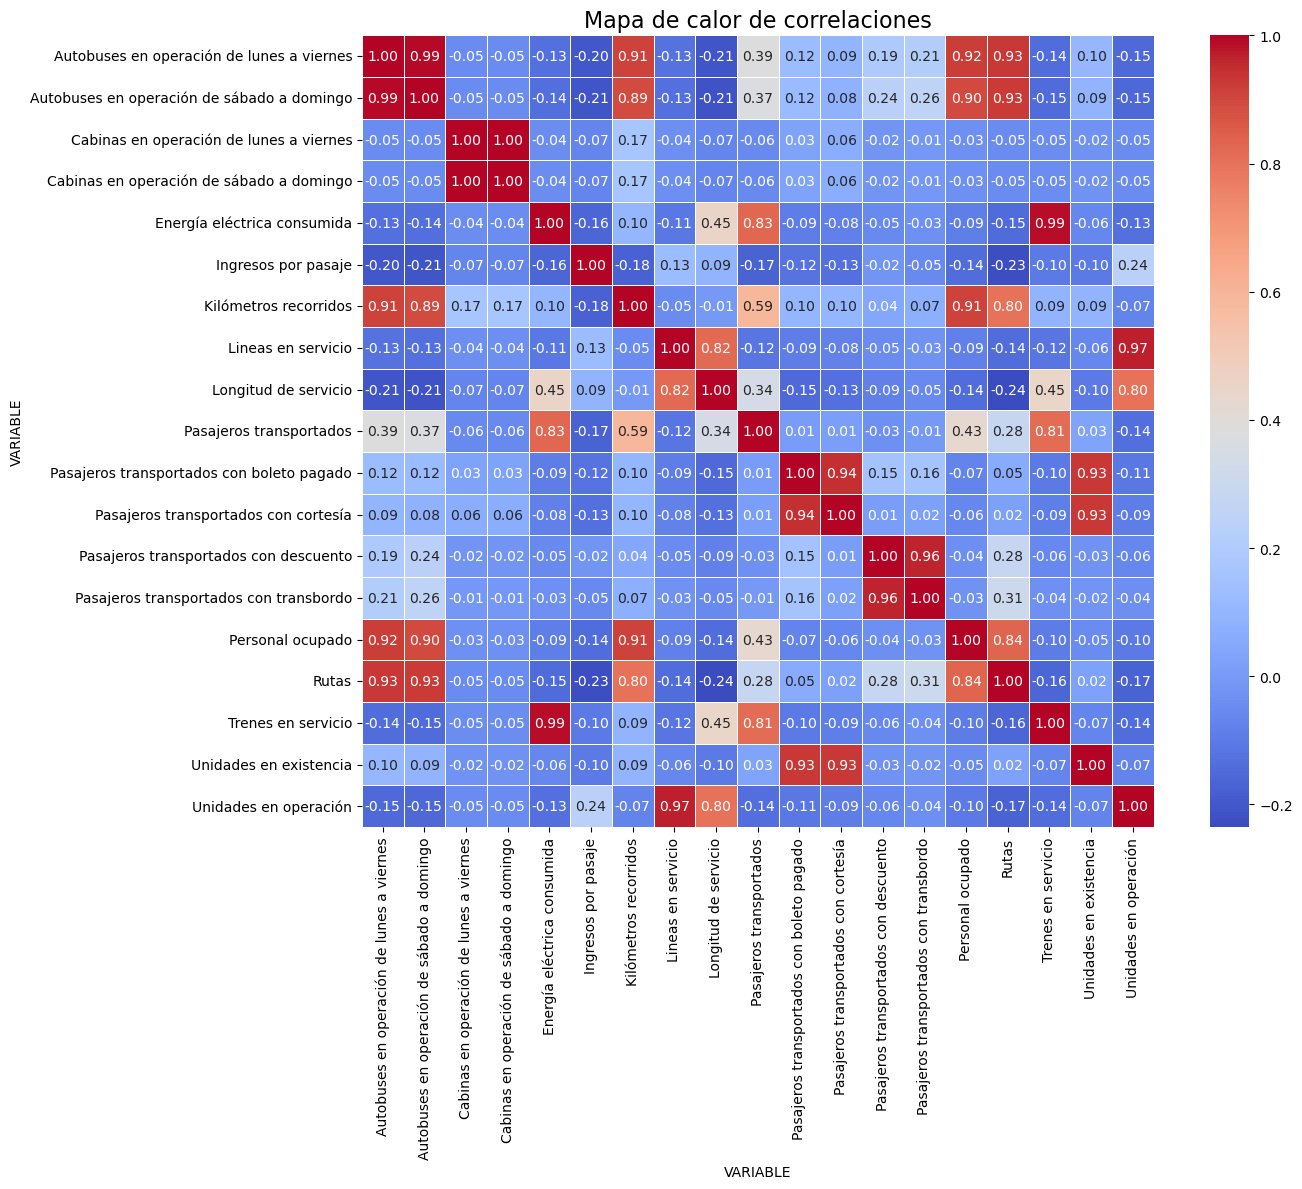

In [73]:
# matriz de correlación
corr_matrix = df_wide[numerics].corr()

# Crear el mapa de calor
plt.figure(figsize=(15, 12))  # Tamaño de la figura
sns.heatmap(corr_matrix,
            annot=True,      # Mostrar los valores dentro de las celdas
            fmt=".2f",       # Formato de los números
            cmap="coolwarm", # Paleta de colores
            cbar=True,       # Mostrar barra de colores
            square=True,     # Celdas cuadradas
            linewidths=0.5)  # Líneas entre celdas
plt.title('Mapa de calor de correlaciones', fontsize=16)
plt.tight_layout()  # Ajustar márgenes
plt.show()

<Axes: xlabel='TRANSPORTE', ylabel='ENTIDAD'>

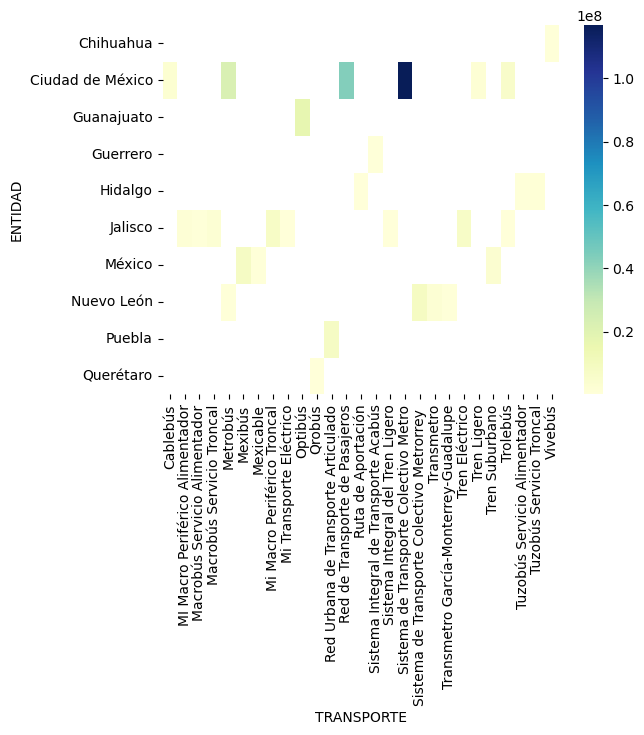

In [74]:
heatmap_data = df_wide.groupby(['ENTIDAD', 'TRANSPORTE'])['Pasajeros transportados'].mean().unstack()
sns.heatmap(heatmap_data, cmap="YlGnBu")

In [75]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Seleccionar solo las columnas numéricas que quieres escalar
numeric_cols = ['Autobuses en operación de lunes a viernes', 'Autobuses en operación de sábado a domingo',
                'Cabinas en operación de lunes a viernes', 'Cabinas en operación de sábado a domingo',
                'Energía eléctrica consumida', 'Ingresos por pasaje', 'Kilómetros recorridos', 'Lineas en servicio',
                'Longitud de servicio', 'Pasajeros transportados', 'Pasajeros transportados con boleto pagado',
                'Pasajeros transportados con cortesía', 'Pasajeros transportados con descuento',
                'Pasajeros transportados con transbordo', 'Personal ocupado', 'Rutas', 'Trenes en servicio',
                'Unidades en existencia', 'Unidades en operación']

# Escalar las columnas seleccionadas
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_wide[numeric_cols])
scaled_df = pd.DataFrame(scaled_data, index=df_wide.index, columns=numeric_cols)

# Mantener las otras columnas sin escalar
non_scaled_cols = df_wide.drop(columns=numeric_cols)

# Unir las columnas escaladas y no escaladas
df_wide_scaled = pd.concat([scaled_df, non_scaled_cols], axis=1)

# (Opcional) Reordenar columnas si lo deseas
df_wide_scaled = df_wide_scaled[df_wide.columns]  # si quieres conservar el orden original
df_wide_scaled

,ANIO,MES,ENTIDAD,TRANSPORTE,Autobuses en operación de lunes a viernes,Autobuses en operación de sábado a domingo,Cabinas en operación de lunes a viernes,Cabinas en operación de sábado a domingo,Energía eléctrica consumida,Ingresos por pasaje,...,Pasajeros transportados,Pasajeros transportados con boleto pagado,Pasajeros transportados con cortesía,Pasajeros transportados con descuento,Pasajeros transportados con transbordo,Personal ocupado,Rutas,Trenes en servicio,Unidades en existencia,Unidades en operación
0,1986,Abril,Ciudad de México,Red de Transporte de Pasajeros,6.957320,6.712456,-0.129334,-0.129334,-0.337084,-0.540249,...,3.896695,-0.281395,-0.244492,-0.160070,-0.098324,6.889553,4.329597,-0.364827,-0.192691,-0.385698
1,1986,Abril,Ciudad de México,Sistema de Transporte Colectivo Metro,-0.388474,-0.400686,-0.129334,-0.129334,2.125333,-0.540249,...,2.387928,-0.281395,-0.244492,-0.160070,-0.098324,-0.263626,-0.440349,1.684014,-0.192691,-0.385698
2,1986,Agosto,Ciudad de México,Red de Transporte de Pasajeros,6.659747,6.861041,-0.129334,-0.129334,-0.337084,-0.540249,...,3.778964,-0.281395,-0.244492,-0.160070,-0.098324,6.944133,4.372960,-0.364827,-0.192691,-0.385698
3,1986,Agosto,Ciudad de México,Sistema de Transporte Colectivo Metro,-0.388474,-0.400686,-0.129334,-0.129334,2.276593,-0.540249,...,2.576166,-0.281395,-0.244492,-0.160070,-0.098324,-0.263626,-0.440349,1.764889,-0.192691,-0.385698
4,1986,Diciembre,Ciudad de México,Red de Transporte de Pasajeros,7.469145,6.661127,-0.129334,-0.129334,-0.337084,-0.540249,...,4.779748,-0.281395,-0.244492,-0.160070,-0.098324,6.867975,4.416323,-0.364827,-0.192691,-0.385698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4775,2025,Marzo,Nuevo León,Sistema de Transporte Colectivo Metrorrey,-0.388474,-0.400686,-0.129334,-0.129334,-0.175259,6.954318,...,-0.284226,-0.281395,-0.244492,-0.160070,-0.098324,-0.263626,-0.440349,0.309134,-0.192691,-0.385698
4776,2025,Marzo,Nuevo León,Transmetro,0.070638,0.247682,-0.129334,-0.129334,-0.337084,-0.540249,...,-0.412167,-0.281395,-0.244492,-0.160070,-0.098324,-0.036420,0.231780,-0.364827,-0.192691,-0.385698
4777,2025,Marzo,Nuevo León,Transmetro García-Monterrey-Guadalupe,-0.322158,-0.341253,-0.129334,-0.129334,-0.337084,-0.540249,...,-0.474686,-0.090910,-0.244492,-0.160070,-0.098324,-0.263626,-0.418668,-0.364827,-0.192691,-0.385698
4778,2025,Marzo,Puebla,Red Urbana de Transporte Articulado,0.204970,0.328728,-0.129334,-0.129334,-0.337084,-0.540249,...,-0.281265,1.444971,0.323382,-0.160070,-0.098324,-0.263626,-0.353623,-0.364827,-0.192691,-0.385698


In [76]:
from sklearn.decomposition import PCA

# Seleccionar solo columnas numéricas antes de aplicar PCA
df_numeric_only = df_wide_scaled.select_dtypes(include=['number'])

# Aplicar PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(df_numeric_only)

# Matriz de componentes principales (scores)
pca_scores = pd.DataFrame(X_pca, index=df_wide_scaled.index,
                          columns=[f'PC{i+1}' for i in range(3)])

pca_scores


,PC1,PC2,PC3
0,13.799118,3.283136,-2.132020
1,-0.213823,2.782358,2.331322
2,13.698652,3.221210,-2.168009
3,-0.170661,2.969059,2.478137
4,14.467304,3.731952,-1.917140
...,...,...,...
4775,-1.645219,-0.084462,-1.018671
4776,0.244757,-0.504015,-0.509230
4777,-0.642729,-0.691242,-0.232073
4778,0.355676,-1.166119,0.490599


In [77]:
# Cada columna de pca.components_ es un vector de cargas para ese PC
loadings = pd.DataFrame(pca.components_.T,
                        index=df_numeric_only.columns,
                        columns=[f'PC{i+1}' for i in range(3)])

loadings

,PC1,PC2,PC3
Autobuses en operación de lunes a viernes,0.428354,0.028063,-0.098376
Autobuses en operación de sábado a domingo,0.426204,0.022917,-0.105088
Cabinas en operación de lunes a viernes,0.004121,-0.076339,0.031307
Cabinas en operación de sábado a domingo,0.004121,-0.076339,0.031307
Energía eléctrica consumida,-0.016053,0.402553,0.380750
Ingresos por pasaje,-0.127326,-0.004278,-0.148917
Kilómetros recorridos,0.398157,0.139523,-0.002646
Lineas en servicio,-0.130325,0.164818,-0.196721
Longitud de servicio,-0.137223,0.373120,0.028706
Pasajeros transportados,0.198308,0.387999,0.306480


In [78]:
# Crear diccionario de variables importantes por componente principal
important_vars = {}

for pc in loadings.columns:
    # Seleccionar variables con carga absoluta >= 0.3
    vars_pc = loadings[pc].loc[loadings[pc].abs() >= 0.3].index.tolist()
    important_vars[pc] = vars_pc
    print(f"{pc}: {', '.join(vars_pc)}")


PC1: Autobuses en operación de lunes a viernes, Autobuses en operación de sábado a domingo, Kilómetros recorridos, Personal ocupado, Rutas
PC2: Energía eléctrica consumida, Longitud de servicio, Pasajeros transportados, Pasajeros transportados con boleto pagado, Pasajeros transportados con cortesía, Trenes en servicio
PC3: Energía eléctrica consumida, Pasajeros transportados, Pasajeros transportados con boleto pagado, Pasajeros transportados con cortesía, Trenes en servicio, Unidades en existencia


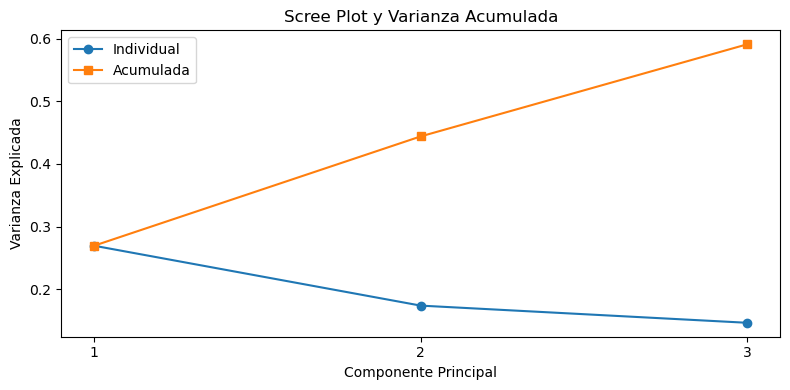

In [81]:
# --------------------------------------------------------
# 2) Scree plot y varianza explicada
# --------------------------------------------------------
explained = pca.explained_variance_ratio_              # Varianza individual
cum_explained = explained.cumsum()                     # Varianza acumulada

plt.figure(figsize=(8,4))
plt.plot(range(1, 4), explained, marker='o', label='Individual')
plt.plot(range(1, 4), cum_explained, marker='s', label='Acumulada')
plt.xticks([1,2,3])
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Explicada')
plt.title('Scree Plot y Varianza Acumulada')
plt.legend()
plt.tight_layout()
plt.show()


In [82]:
# --------------------------------------------------------
# 3) DataFrame de scores (proyecciones) en los PCs
# --------------------------------------------------------
pc_labels = [f'PC{i+1}' for i in range(pca.n_components_)]
pca_scores = pd.DataFrame(X_pca, columns=pc_labels, index=df_numeric_only.index)

# --------------------------------------------------------
# 4) Cálculo de loadings y variables importantes
# --------------------------------------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_numeric_only.columns,
    columns=pc_labels
)

# Extraer variables con carga absoluta ≥ 0.3 en cada PC
threshold = 0.3
for pc in pc_labels:
    vars_pc = loadings.index[loadings[pc].abs() >= threshold].tolist()
    print(f"{pc} (|carga| ≥ {threshold}): {vars_pc}")


PC1 (|carga| ≥ 0.3): ['Autobuses en operación de lunes a viernes', 'Autobuses en operación de sábado a domingo', 'Kilómetros recorridos', 'Personal ocupado', 'Rutas']
PC2 (|carga| ≥ 0.3): ['Energía eléctrica consumida', 'Longitud de servicio', 'Pasajeros transportados', 'Pasajeros transportados con boleto pagado', 'Pasajeros transportados con cortesía', 'Trenes en servicio']
PC3 (|carga| ≥ 0.3): ['Energía eléctrica consumida', 'Pasajeros transportados', 'Pasajeros transportados con boleto pagado', 'Pasajeros transportados con cortesía', 'Trenes en servicio', 'Unidades en existencia']


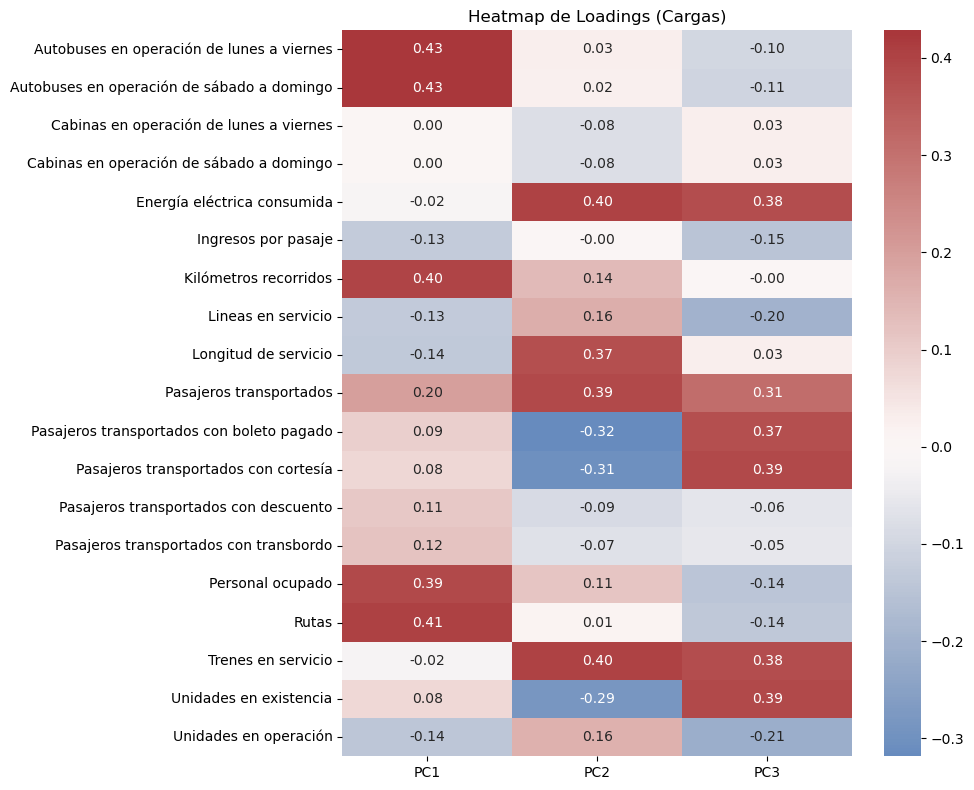

In [83]:
# --------------------------------------------------------
# 5) Heatmap de loadings
# --------------------------------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title('Heatmap de Loadings (Cargas)')
plt.tight_layout()
plt.show()


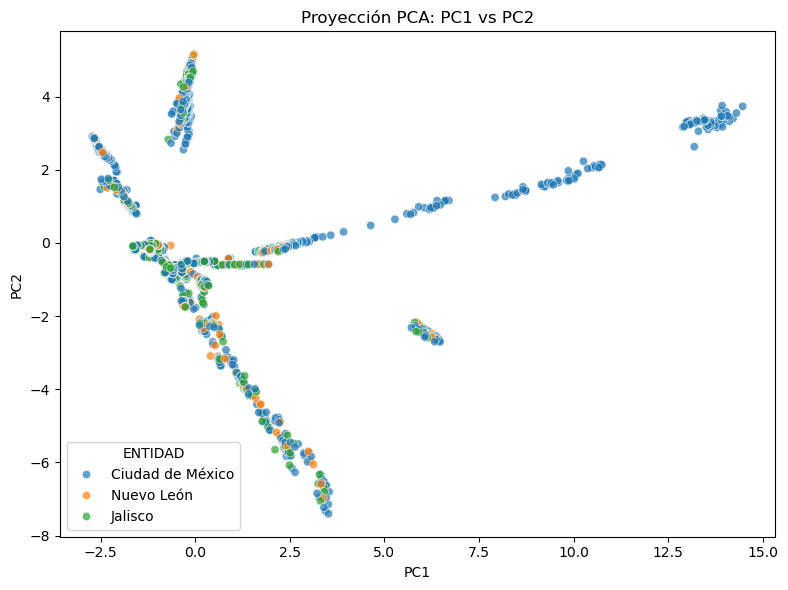

In [84]:
# --------------------------------------------------------
# 6) Scatterplot de scores: PC1 vs PC2 coloreado por categoría
# --------------------------------------------------------
# Supongamos que 'ENTIDAD' es una columna categórica de tu DataFrame original df
plot_df = pca_scores.join(df['ENTIDAD'])

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='ENTIDAD', data=plot_df, alpha=0.7)
plt.title('Proyección PCA: PC1 vs PC2')
plt.tight_layout()
plt.show()